In [21]:
from numba import cuda
import threading

import math
import numpy as np
import matplotlib.pyplot as plt
from time import time, perf_counter

In [ ]:
device = cuda.get_current_device()
device_name = device.name
if isinstance(device_name, bytes):
    device_name = device_name.decode('utf-8')

compute_capability = device.compute_capability
multiprocessor_count = getattr(device, "MULTIPROCESSOR_COUNT")
core_count = 108*64 # Ampere architecture
free_memory, total_memory = cuda.current_context().get_memory_info()
memory_size = total_memory

print(f"Device Name: {device_name}")
print(f"Compute Capability: {compute_capability[0]}.{compute_capability[1]}")
print(f"Core Count: {core_count}")
print(f"Multiprocessor Count: {multiprocessor_count}")
print(f"Memory Size: {memory_size} bytes")

Device Name: NVIDIA A100-SXM4-40GB
Compute Capability: 8.0
Core Count: 6912
Multiprocessor Count: 108
Memory Size: 42405855232 bytes


In [ ]:
select_cuda=cuda.select_device(0)
print(f"Select cuda: {select_cuda}")

Select cuda: <CUDA device 0 'NVIDIA A100-SXM4-40GB'>


In [16]:
@cuda.jit
def grayscale_gpu(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


def grayscale_cpu(image):
    gray_image = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            avg = np.mean(image[i, j])
            gray_image[i, j] = [avg, avg, avg]
    return gray_image

@cuda.jit
def grayscale_gpu_2d(src, dst):
    x, y = cuda.grid(2)
    if y < src.shape[0] and x < src.shape[1]:
        r = np.int32(src[y, x, 0])
        g_ = np.int32(src[y, x, 1])
        b = np.int32(src[y, x, 2])
        g = np.uint8((r + g_ + b) / 3)
        dst[y, x, 0] = g
        dst[y, x, 1] = g
        dst[y, x, 2] = g


def run_grayscale_gpu_2d(img, block_size=(8, 8)):
    img_c = np.ascontiguousarray(img)
    gray = np.zeros_like(img_c)
    height, width = img_c.shape[0], img_c.shape[1]
    blocks_per_grid = (math.ceil(width / block_size[0]),
                       math.ceil(height / block_size[1]))
    d_img = cuda.to_device(img_c)
    d_gray = cuda.to_device(gray)
    start = time()
    grayscale_gpu_2d[blocks_per_grid, block_size](d_img, d_gray)
    cuda.synchronize()
    end = time()
    return d_gray.copy_to_host(), end - start


def make_singlethread(inner_func):
  """
    Run the given function inside a single thread.
  """
  def func(*args):
    length = len(args[0])
    result = np.empty(length, dtype=np.float64)
    inner_func(result, *args)
    return result
  return func



def make_multithread(inner_func, numthreads):
    """
    Run the given function inside *numthreads* threads, splitting
    its arguments into equal-sized chunks.
    """
    def func_mt(*args):
        length = len(args[0])
        result = np.empty(length, dtype=np.float64)
        args = (result,) + args
        chunklen = (length + numthreads - 1) // numthreads
        chunks = [[arg[i * chunklen:(i + 1) * chunklen] for arg in args] for i in range(numthreads)]
        threads = [threading.Thread(target=inner_func, args=chunk)
                   for chunk in chunks]
        for thread in threads:
            thread.start()
        for thread in threads:
            thread.join()
        return result
    return func_mt



def block_config(bx, by):
    threads_per_block = bx * by

    if threads_per_block > MAX_THREADS_PER_BLOCK:
        return {
            "block": f"{bx}x{by}",
            "threads/block": threads_per_block,
            "valid": False,
            "blocks/SM": 0,
            "threads/SM": 0,
            "warps/block": math.ceil(threads_per_block / WARP_SIZE),
            "occupancy": 0.0,
            "limited_by": "over 512 threads/block"
        }

    by_threads = MAX_THREADS_PER_SM // threads_per_block
    by_blocks  = MAX_BLOCKS_PER_SM
    blocks_per_sm = min(by_threads, by_blocks)
    limited_by = "threads/SM" if by_threads <= by_blocks else "blocks/SM"

    threads_per_sm = blocks_per_sm * threads_per_block
    occupancy = threads_per_sm / MAX_THREADS_PER_SM

    return {
        "block": f"{bx}x{by}",
        "threads/block": threads_per_block,
        "valid": True,
        "blocks/SM": blocks_per_sm,
        "threads/SM": threads_per_sm,
        "warps/block": math.ceil(threads_per_block / WARP_SIZE),
        "occupancy": occupancy,
        "limited_by": limited_by
    }

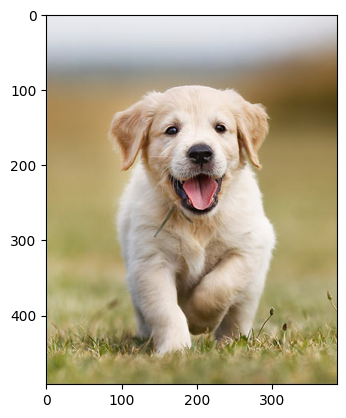

In [17]:
img_src = "/content/drive/MyDrive/DATA/HPC/image.jpg"
img=plt.imread(img_src, format=None)
plt.imshow(img)
plt.show()

In [ ]:
# Flatten image into 1D array of RGB
pixel_count = img.shape[0] * img.shape[1]
img_flat = img.reshape(pixel_count, 3)

print(f"Shape of flattened image: {img_flat.shape}")

Shape of flattened image: (190404, 3)


### Grayscale Conversion using CPU

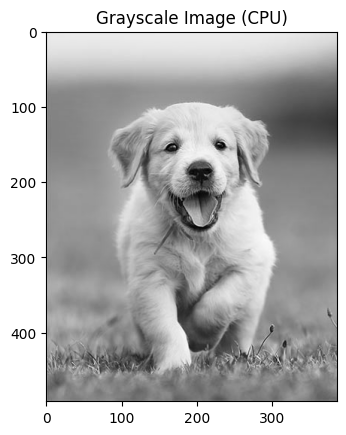

CPU Grayscale conversion took: 1.3464 seconds


In [ ]:
start_time_cpu = time()
gray_image_cpu = grayscale_cpu(img)
end_time_cpu = time()

plt.imshow(gray_image_cpu)
plt.title('Grayscale Image (CPU)')
plt.show()

print(f"CPU Grayscale conversion took: {end_time_cpu - start_time_cpu:.4f} seconds")

### Grayscale Conversion using GPU (Numba CUDA)

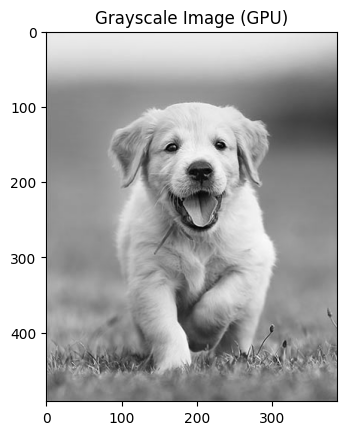

GPU Grayscale conversion took: 0.0004 seconds


In [ ]:
img_flat = np.array(img_flat, copy=True)
gray_flat = np.zeros_like(img_flat)

threads_per_block = 64
blocks_per_grid = (pixel_count + threads_per_block - 1) // threads_per_block

d_img = cuda.to_device(img_flat)
d_gray = cuda.to_device(gray_flat)

start_time_gpu = time()

grayscale_gpu[blocks_per_grid, threads_per_block](d_img, d_gray)

cuda.synchronize()

end_time_gpu = time()

gray_flat = d_gray.copy_to_host()
gray_image_gpu = gray_flat.reshape(img.shape)

plt.imshow(gray_image_gpu)
plt.title('Grayscale Image (GPU)')
plt.show()

print(f"GPU Grayscale conversion took: {end_time_gpu - start_time_gpu:.4f} seconds")

# 2D images

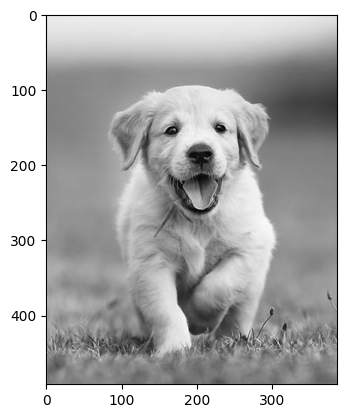

In [22]:
test, t = run_grayscale_gpu_2d(img)
plt.imshow(test)
plt.show()

In [ ]:
MAX_THREADS_PER_BLOCK = 512
MAX_THREADS_PER_SM = 1024
MAX_BLOCKS_PER_SM = 8
WARP_SIZE = 32

In [31]:
block_size = [(8, 8), (16, 16), (32, 32)]
results = [block_config(bx, by) for bx, by in block_size]
times = []

for bs in block_size:
  _, t = run_grayscale_gpu_2d(img, bs)
  times.append(t)
  print(f"Block {bs}: {t:.6f} s")

Block (8, 8): 0.000344 s
Block (16, 16): 0.000293 s
Block (32, 32): 0.000285 s


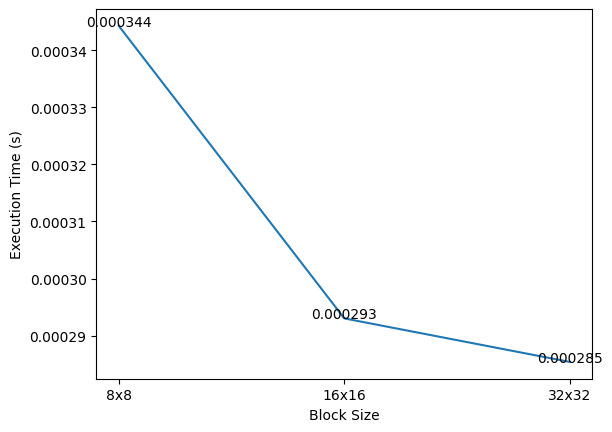

In [32]:
x_labels = [f"{bx}x{by}" for bx, by in block_size]

plt.plot(x_labels, times)
for xl, y in zip(x_labels, times):
    plt.text(xl, y, f"{y:.6f}", ha="center")

plt.xlabel("Block Size")
plt.ylabel("Execution Time (s)")
plt.show()

In [33]:
print(f"{'Block':<8}{'Thr/blk':<9}{'Valid':<7}{'Blk/SM':<8}{'Thr/SM':<8}{'Warps/blk':<10}{'Occupancy':<11}Limitation")
for r in results:
    print(f"{r['block']:<8}{r['threads/block']:<9}{str(r['valid']):<7}{r['blocks/SM']:<8}"
          f"{r['threads/SM']:<8}{r['warps/block']:<10}{r['occupancy']*100:>6.0f}%    {r['limited_by']}")

valid_results = [r for r in results if r["valid"]]
best = max(valid_results, key=lambda r: r["occupancy"])
print(f"\n=> The best block conf: {best['block']} "
      f"(occupancy {best['occupancy']*100:.0f}%, {best['blocks/SM']} blocks/SM)")

Block   Thr/blk  Valid  Blk/SM  Thr/SM  Warps/blk Occupancy  Limitation
8x8     64       True   8       512     2             33%    blocks/SM
16x16   256      True   6       1536    8            100%    threads/SM
32x32   1024     False  0       0       32             0%    over 512 threads/block

=> The best block conf: 16x16 (occupancy 100%, 6 blocks/SM)


# Ex2

In [ ]:
MAX_THREADS_PER_SM = 1536
MAX_BLOCKS_PER_SM  = 4
candidates = [128, 256, 512, 1024]

In [ ]:
def analyze(threads_per_block):
    by_threads = MAX_THREADS_PER_SM // threads_per_block
    blocks_per_sm = min(by_threads, MAX_BLOCKS_PER_SM)
    limited_by = "threads/SM" if by_threads < MAX_BLOCKS_PER_SM else "blocks/SM"
    threads_per_sm = blocks_per_sm * threads_per_block
    return blocks_per_sm, threads_per_sm, threads_per_sm / MAX_THREADS_PER_SM, limited_by


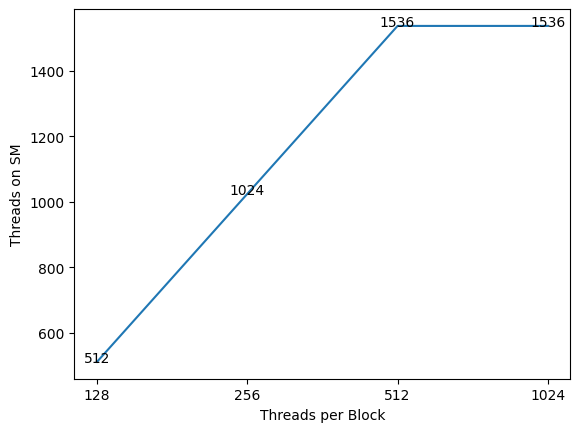

In [ ]:
threads_on_sm = []
for t in candidates:
    blocks = min(MAX_THREADS_PER_SM / t, MAX_BLOCKS_PER_SM)
    threads_on_sm.append(blocks * t)

x_labels = [str(t) for t in candidates]
plt.plot(x_labels, threads_on_sm)
for xl, y in zip(x_labels, threads_on_sm):
    plt.text(xl, y, f"{y:.0f}", ha="center")

plt.xlabel("Threads per Block")
plt.ylabel("Threads on SM")
plt.show()

# Ex3

In [35]:
N = 2000
threads_per_block = 512

blocks_per_grid = math.ceil(N / threads_per_block)
total_threads = blocks_per_grid * threads_per_block
idle_threads = total_threads - N

print(f"Blocks: {blocks_per_grid}")
print(f"Grid Thread: {total_threads}")
print(f"Threads woker: {N}")
print(f"Threads exist: {idle_threads}")

Blocks: 4
Grid Thread: 2048
Threads woker: 2000
Threads exist: 48
